<a href="https://colab.research.google.com/github/LindaN731/Investment-Memo-ffr-deposit/blob/main/Deposit_beta_data_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

"""
Deposit Beta Project - Summary Statistics
==========================================
根据数据描述生成描述性统计表格
"""

import pandas as pd
import numpy as np

# ============================================================
# 1. 读取数据（把路径改成你自己的文件路径）
# ============================================================


df = pd.read_csv("/content/deposit_beta_data.csv")

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

print(f"数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")


# ============================================================
# 2. 定义要统计的变量（分组展示更清晰）
# ============================================================

# 核心回归变量
regression_vars = {
    "depositratechange": "∆ Deposit Rate",
    "ffrchange":     "∆ Fed Funds Rate",
    "depositrate":    "Deposit Rate",
}

# 控制变量（滞后一期，用于回归）
control_vars = {
    "lassetslag": "Bank Size (lag)",
    "niblag":   "NIB Ratio (lag)",
    "roalag":   "ROA (lag)",
    "leveragelag": "Leverage Ratio (lag)",
    "loanlag":   "Loan Ratio (lag)",
    "liquiditylag": "Liquidity Ratio (lag)"
}
#Size — 大银行定价能力更强，对利率变化反应可能不同
#NIB Ratio — 非利息存款越多，银行对存款利率越不敏感（这部分客户本来就不拿利息）
#ROA — 盈利能力强的银行可能不需要靠高利率来吸引存款
#Leverage — 资本越充足，银行越稳健，行为可能不同
#Loan Ratio — 贷款多的银行更需要存款来融资，可能更积极跟进利率
#Liquidity — 流动性高的银行不缺钱，不需要用高利率吸引存款



# 原始水平变量（可选，便于理解数据）
level_vars = {
    "lassets":    "Bank Size",
    "nib":        "NIB Ratio",
    "roa":        "ROA",
    "leverage":   "Leverage Ratio",
    "loan":       "Loan Ratio",
    "liquidity":  "Liquidity Ratio",
}

all_vars = {**regression_vars, **control_vars, **level_vars}


# ============================================================
# 3. 生成描述性统计表
# ============================================================

def make_summary_table(df, var_dict, title="Summary Statistics"):
    """
    生成描述性统计表，包含：
    N, Mean, Std Dev, Min, P25, Median, P75, Max
    """
    rows = []

    for col, label in var_dict.items():
        if col not in df.columns:
            print(f"⚠️  警告：找不到列 '{col}'，已跳过")
            continue

        s = df[col].dropna()
        row = {
            "Variable": label,
            "N":    int(s.count()),
            "Mean":   s.mean(),
            "Std Dev": s.std(),
            "Min":    s.min(),
            "P25":    s.quantile(0.25),
            "Median":   s.median(),
            "P75":    s.quantile(0.75),
            "Max":     s.max(),
        }
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("Variable")
    return summary


# 生成完整统计表
summary = make_summary_table(df, all_vars)

# ============================================================
# 4. 格式化输出（小数位控制）
# ============================================================

def format_summary(df_summary):
    """
    四舍五入到4位小数，N列保持整数
    """
    fmt = df_summary.copy()
    fmt["N"] = fmt["N"].astype(int)
    numeric_cols = [c for c in fmt.columns if c != "N"]
    fmt[numeric_cols] = fmt[numeric_cols].round(4)
    return fmt

summary_fmt = format_summary(summary)

print("\n" + "="*80)
print("SUMMARY STATISTICS - DEPOSIT BETA PROJECT")
print("="*80)
print(summary_fmt.to_string())
print("="*80)



# ============================================================
# 5. 额外：分年度 / 分季度统计（可选）
# ============================================================

if "year" in df.columns:
    print("\n--- Year Sample ---")
    print(df.groupby("year")["depositratechange"].count().rename("N observations"))

if "qtr" in df.columns:
    print("\n--- Quarter Average ∆ Deposit Rate ---")
    print(df.groupby("qtr")["depositratechange"].mean().round(4))


# ============================================================
# 6. 快速相关矩阵（回归前看看变量关系）
# ============================================================

reg_cols = [c for c in all_vars.keys() if c in df.columns]
corr_matrix = df[reg_cols].corr().round(3)

print("\n--- correlation matrix ---")
print(corr_matrix.to_string())

import statsmodels.formula.api as smf

# ============================================================
# 7. linear regression of the all
# ============================================================
# OLS 回归（不加固定效应）
model_ols = smf.ols(
    formula = "depositratechange ~ ffrchange + lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()

print(model_ols.summary())

# ============================================================
# 8. Linear regression including the bank fixed effects
# ============================================================
!pip install linearmodels
from linearmodels.panel import PanelOLS

# 设置 panel 结构（告诉 python 哪个是银行ID，哪个是时间）
df_panel = df.set_index(["IDRSSD", "date"])

model_panel = PanelOLS.from_formula(
    "depositratechange ~ ffrchange + lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag + EntityEffects",
    data = df_panel
).fit(cov_type="clustered", cluster_entity=True)

print(model_panel.summary)

# ============================================================
# 9. Linear regression to see whether each control variable is a influencer
# ============================================================
# 1. bank size
model_size = smf.ols(
    formula = "depositratechange ~ ffrchange + lassetslag + ffrchange:lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== Bank Size ===")
print(model_size.summary())

# 2. NIB Ratio
model_nib = smf.ols(
    formula = "depositratechange ~ ffrchange + niblag + ffrchange:niblag + lassetslag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== NIB Ratio ===")
print(model_nib.summary())

# 3. ROA
model_roa = smf.ols(
    formula = "depositratechange ~ ffrchange + roalag + ffrchange:roalag + lassetslag + niblag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== ROA ===")
print(model_roa.summary())

# 4. Leverage
model_leverage = smf.ols(
    formula = "depositratechange ~ ffrchange + leveragelag + ffrchange:leveragelag + lassetslag + niblag + roalag + loanlag + liquiditylag",
    data = df
).fit()
print("=== Leverage ===")
print(model_leverage.summary())

# 5. Loan Ratio
model_loan = smf.ols(
    formula = "depositratechange ~ ffrchange + loanlag + ffrchange:loanlag + lassetslag + niblag + roalag + leveragelag + liquiditylag",
    data = df
).fit()
print("=== Loan Ratio ===")
print(model_loan.summary())

# 6. Liquidity
model_liquidity = smf.ols(
    formula = "depositratechange ~ ffrchange + liquiditylag + ffrchange:liquiditylag + lassetslag + niblag + roalag + leveragelag + loanlag",
    data = df
).fit()
print("=== Liquidity ===")
print(model_liquidity.summary())


数据形状: (167560, 19)
列名: ['IDRSSD', 'date', 'year', 'qtr', 'depositrate', 'depositratechange', 'ffrchange', 'lassets', 'lassetslag', 'nib', 'niblag', 'roa', 'roalag', 'leverage', 'leveragelag', 'loan', 'loanlag', 'liquidity', 'liquiditylag']

SUMMARY STATISTICS - DEPOSIT BETA PROJECT
                            N     Mean  Std Dev     Min      P25   Median      P75      Max
Variable                                                                                   
∆ Deposit Rate         163371   0.0394   0.1907 -3.8465  -0.0362   0.0070   0.0865   3.8465
∆ Fed Funds Rate       163371   0.0907   0.4628 -1.2000  -0.0100   0.0233   0.2500   1.4633
Deposit Rate           167560   1.0178   0.8718  0.0453   0.3725   0.7097   1.4366   3.8918
Bank Size (lag)        163371  12.6309   1.3464  7.9568  11.7225  12.5009  13.3703  18.3503
NIB Ratio (lag)        163371   0.2296   0.1147  0.0000   0.1566   0.2211   0.2939   0.6170
ROA (lag)              163371   1.0561   0.8253 -2.2736   0.6347   1.0147

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# 1. 读取数据（把路径改成你自己的文件路径）
# ============================================================


df = pd.read_csv("/content/deposit_beta_data.csv")

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

print(f"数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")


# ============================================================
# 2. 定义要统计的变量（分组展示更清晰）
# ============================================================

# 核心回归变量
regression_vars = {
    "depositratechange": "∆ Deposit Rate",
    "ffrchange":     "∆ Fed Funds Rate",
    "depositrate":    "Deposit Rate",
}

# 控制变量（滞后一期，用于回归）
control_vars = {
    "lassetslag": "Bank Size (lag)",
    "niblag":   "NIB Ratio (lag)",
    "roalag":   "ROA (lag)",
    "leveragelag": "Leverage Ratio (lag)",
    "loanlag":   "Loan Ratio (lag)",
    "liquiditylag": "Liquidity Ratio (lag)"
}
#Size — 大银行定价能力更强，对利率变化反应可能不同
#NIB Ratio — 非利息存款越多，银行对存款利率越不敏感（这部分客户本来就不拿利息）
#ROA — 盈利能力强的银行可能不需要靠高利率来吸引存款
#Leverage — 资本越充足，银行越稳健，行为可能不同
#Loan Ratio — 贷款多的银行更需要存款来融资，可能更积极跟进利率
#Liquidity — 流动性高的银行不缺钱，不需要用高利率吸引存款



# 原始水平变量（可选，便于理解数据）
level_vars = {
    "lassets":    "Bank Size",
    "nib":        "NIB Ratio",
    "roa":        "ROA",
    "leverage":   "Leverage Ratio",
    "loan":       "Loan Ratio",
    "liquidity":  "Liquidity Ratio",
}

all_vars = {**regression_vars, **control_vars, **level_vars}


# ============================================================
# 3. OLS model: all the lagged variables interacting with deltaFFR
# ============================================================
from linearmodels.panel import PanelOLS

df_panel = df.set_index(["IDRSSD", "date"])

formula = """
depositratechange ~
    ffrchange +
    lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag +
    ffrchange:lassetslag +
    ffrchange:niblag +
    ffrchange:roalag +
    ffrchange:leveragelag +
    ffrchange:loanlag +
    ffrchange:liquiditylag
"""

model_panel = PanelOLS.from_formula(
    formula,
    data=df_panel
).fit(cov_type="clustered", cluster_entity=True)

print(model_panel.summary)

数据形状: (167560, 19)
列名: ['IDRSSD', 'date', 'year', 'qtr', 'depositrate', 'depositratechange', 'ffrchange', 'lassets', 'lassetslag', 'nib', 'niblag', 'roa', 'roalag', 'leverage', 'leveragelag', 'loan', 'loanlag', 'liquidity', 'liquiditylag']
                          PanelOLS Estimation Summary                           
Dep. Variable:      depositratechange   R-squared:                        0.2700
Estimator:                   PanelOLS   R-squared (Between):              0.8384
No. Observations:              163371   R-squared (Within):               0.2410
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.2700
Time:                        17:27:57   Log-likelihood                 6.121e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4647.7
Entities:                        4189   P-value                           0.0000
Avg Obs:                       

In [ ]:
"""
Deposit Beta Analysis — 完整研究代码
导师: Derek Stimel | 学生: Yihan (Linda) Niu

三个模型:
  1. 简化 OLS（hiking/cutting/pause + 控制变量，无交互项）
  2. Stepwise Backward Regression
  3. LASSO Regression


"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. 加载数据
# ============================================
df = pd.read_csv('/content/deposit_beta_data.csv')

# 删除缺失值
df_clean = df.dropna().copy()
print(f"Total effective data number: {len(df_clean)}")
print()

# ============================================
# 2. 创建 hiking / cutting / pause 虚拟变量
# ============================================
df_clean['hiking'] = (df_clean['ffrchange'] > 0).astype(float)
df_clean['cutting'] = (df_clean['ffrchange'] < 0).astype(float)
df_clean['pause']   = (df_clean['ffrchange'] == 0).astype(float)

print(f"hiking  (加息): {df_clean['hiking'].sum():.0f} 条观测")
print(f"cutting (降息): {df_clean['cutting'].sum():.0f} 条观测")
print(f"pause   (不变): {df_clean['pause'].sum():.0f} 条观测")
print()

# 自变量列表（不含交互项）
all_vars = [
    'hiking', 'cutting', 'pause',
    'lassetslag', 'niblag', 'roalag',
    'leveragelag', 'loanlag', 'liquiditylag'
]

y = df_clean['depositratechange']
X = df_clean[all_vars]

# ============================================
# 模型 1: 简化 OLS
# ============================================
print("=" * 70)
print("Model 1: OLS with out Interaction Term")
print("hiking/cutting/pause + control variable but no interaction term")
print("=" * 70)

X1 = sm.add_constant(X)
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# ============================================
# 模型 2: Stepwise Backward Regression
# ============================================
print("\n" + "=" * 70)
print("Model 2: Stepwise Backward Regression")
print("从全模型开始，逐步剔除 p > 0.05 的变量")
print("=" * 70)

remaining_vars = all_vars.copy()
step = 1

while len(remaining_vars) > 0:
    X_current = sm.add_constant(df_clean[remaining_vars])
    model = sm.OLS(y, X_current).fit()

    pvals = model.pvalues.drop('const')
    max_p = pvals.max()
    worst_var = pvals.idxmax()

    if max_p > 0.05:
        print(f"  第 {step} 步: 剔除 '{worst_var}' (p = {max_p:.6f})")
        remaining_vars.remove(worst_var)
        step += 1
    else:
        break

print(f"\n✅ 最终保留的变量 ({len(remaining_vars)} 个):")
for v in remaining_vars:
    print(f"   - {v}")
print()

X_final = sm.add_constant(df_clean[remaining_vars])
model2 = sm.OLS(y, X_final).fit()
print(model2.summary())

# ============================================
# 模型 3: LASSO Regression
# ============================================
print("\n" + "=" * 70)
print("模型 3: LASSO Regression（L1 正则化 + 交叉验证）")
print("=" * 70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"最佳 lambda (alpha): {lasso_cv.alpha_:.6f}")
print(f"R²:                 {lasso_cv.score(X_scaled, y):.4f}")
print()

coef_df = pd.DataFrame({
    'Variable': all_vars,
    'Coefficient': lasso_cv.coef_
})
coef_df['|Coef|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coef|', ascending=False)
print("LASSO 系数（按重要性排序）:")
print(coef_df.to_string(index=False))
print(f"截距 (Intercept): {lasso_cv.intercept_:.6f}")

print("\n" + "=" * 70)
print("=" * 70)


Total effective data number: 163371

hiking  (加息): 92158 条观测
cutting (降息): 58646 条观测
pause   (不变): 12567 条观测

Model 1: OLS with out Interaction Term
hiking/cutting/pause + control variable but no interaction term
                            OLS Regression Results                            
Dep. Variable:      depositratechange   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2892.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:03:26   Log-Likelihood:                 49745.
No. Observations:              163371   AIC:                        -9.947e+04
Df Residuals:                  163362   BIC:                        -9.938e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                       

数据维度: (167560, 20)
时间跨度: 2016-03-31 至 2025-12-31
银行数量: 4189
变量列表: ['IDRSSD', 'date', 'year', 'qtr', 'depositrate', 'depositratechange', 'ffrchange', 'lassets', 'lassetslag', 'nib', 'niblag', 'roa', 'roalag', 'leverage', 'leveragelag', 'loan', 'loanlag', 'liquidity', 'liquiditylag', '_dt']

MODEL 1: FULL-SAMPLE POOLED OLS (Robust Clustered by Bank)
                            OLS Regression Results                            
Dep. Variable:      depositratechange   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     1556.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:38:37   Log-Likelihood:                 57938.
No. Observations:              163371   AIC:                        -1.159e+05
Df Residuals:                  163363   BIC:                        -1.158e+05
Df Model:         

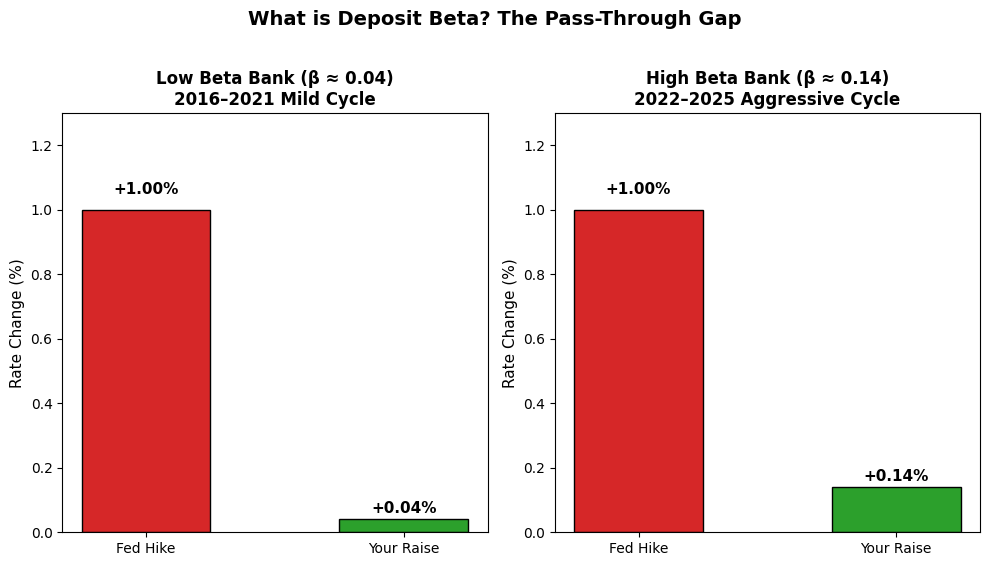

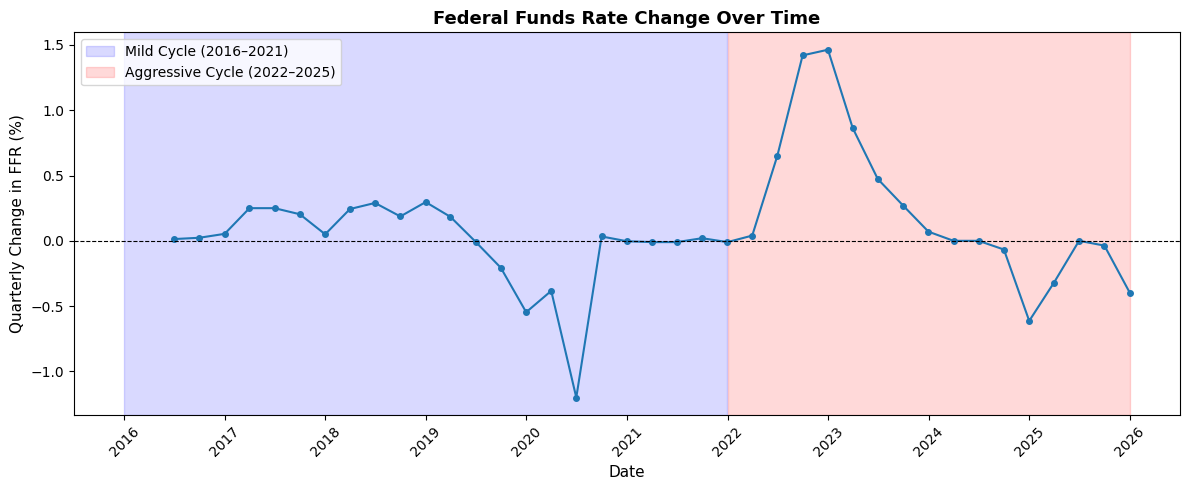

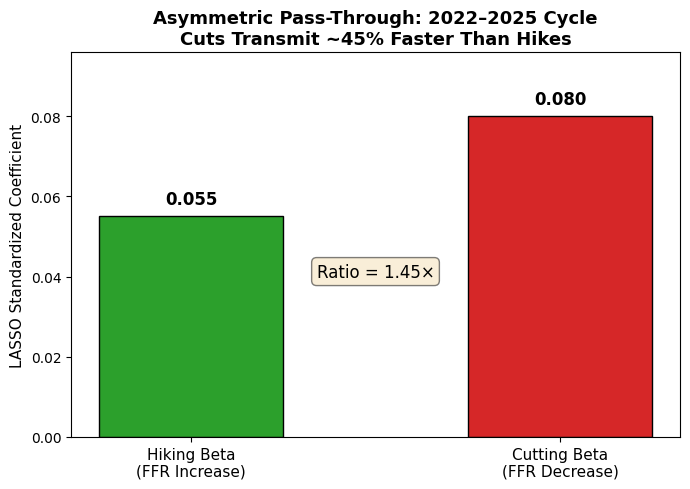

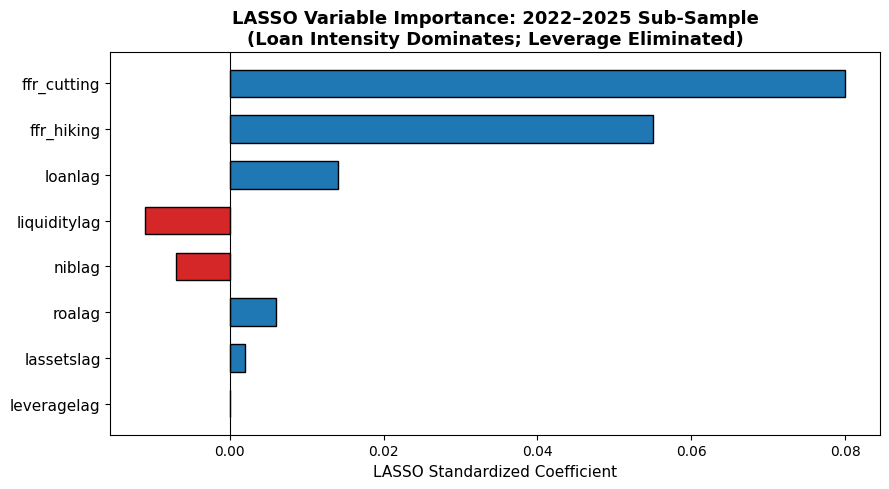

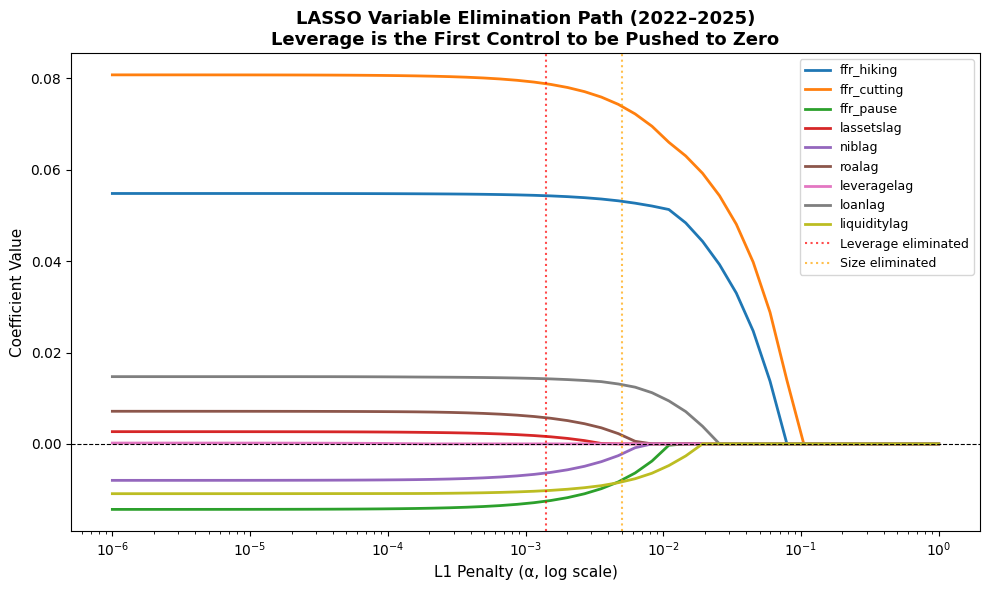


所有模型和图表运行完毕。请检查各图输出，确认数字与 Memo 一致。


In [ ]:

# ============================================
# Deposit Beta Analysis - Complete Colab Script
# 直接复制粘贴到 Google Colab 即可运行
# ============================================

# 1. 安装依赖（Colab 需手动安装 linearmodels）
!pip install linearmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. 读取数据
# ============================================
# 请先在 Colab 左侧文件栏上传 deposit_beta_data.csv
df = pd.read_csv("/content/deposit_beta_data.csv")
df['date'] = pd.to_datetime(df['date'])
df['_dt'] = pd.to_datetime(df['date'])  # 用于时间筛选

print(f"数据维度: {df.shape}")
print(f"时间跨度: {df['date'].min().date()} 至 {df['date'].max().date()}")
print(f"银行数量: {df['IDRSSD'].nunique()}")
print(f"变量列表: {df.columns.tolist()}")

# ============================================
# 3. 定义变量
# ============================================
control_vars = ['lassetslag', 'niblag', 'roalag', 'leveragelag', 'loanlag', 'liquiditylag']

# --- 简化 OLS 方向虚拟变量（对应 Memo Table 1）---
df['hiking'] = (df['ffrchange'] > 0).astype(float)
df['cutting'] = (df['ffrchange'] < 0).astype(float)
df['pause'] = (df['ffrchange'] == 0).astype(float)

# --- Regime 虚拟变量（用于 PanelOLS Regime 模型）---
df['hiking_reg'] = (df['ffrchange'] > 0.1).astype(float)
df['cutting_reg'] = (df['ffrchange'] < -0.1).astype(float)
df['pause_reg'] = df['ffrchange'].between(-0.1, 0.1).astype(float)

# ============================================
# 4. 辅助函数：Robust OLS（按银行聚类）
# ============================================
def run_robust_ols(y, X, groups, title):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': groups}
    )
    print(f"\n{'='*70}")
    print(f"{title} | Bank-Clustered Robust SE")
    print(f"{'='*70}")
    print(model.summary())
    return model

# ============================================
# 5. MODEL 1: 全样本 Pooled OLS（Robust）
# ============================================
print("\n" + "="*80)
print("MODEL 1: FULL-SAMPLE POOLED OLS (Robust Clustered by Bank)")
print("="*80)

# Create the OLS model object first
ols_model = smf.ols(
    formula="depositratechange ~ ffrchange + " + " + ".join(control_vars),
    data=df
)

# Extract the 'IDRSSD' series from the original DataFrame,
# using the row labels that statsmodels actually used for the model.
# This ensures that the 'groups' series has the same length as the model's data.
aligned_groups = df.loc[ols_model.data.row_labels, 'IDRSSD']

# Fit the model with clustered standard errors using the aligned groups
model_full = ols_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': aligned_groups}
)
print(model_full.summary())

# ============================================
# 6. MODEL 2: Sub-Sample 简化 OLS（Robust）—— Memo Table 1
# ============================================
print("\n" + "="*80)
print("MODEL 2: SUB-SAMPLE SIMPLIFIED OLS (Robust) — Memo Table 1")
print("="*80)

simple_vars = ['hiking', 'cutting', 'pause'] + control_vars

for name, mask in [("2016-2021", (df['_dt'] >= '2016') & (df['_dt'] <= '2021')),
                   ("2022-2025", df['_dt'] >= '2022')]:

    sub = df[mask].copy()
    y = sub['depositratechange']
    X = sub[simple_vars]
    groups = sub['IDRSSD']

    # Explicitly handle missing data for y, X, and groups for sm.OLS
    valid_mask = y.notna() & X.notna().all(axis=1)
    y_cleaned = y[valid_mask]
    X_cleaned = X[valid_mask]
    groups_cleaned = groups[valid_mask]

    run_robust_ols(y_cleaned, X_cleaned, groups_cleaned, f"Sub-Sample: {name} (n={len(y_cleaned):,})")

# ============================================
# 7. MODEL 3: PanelOLS + EntityEffects + Clustered（全样本，含交互项）
# ============================================
print("\n" + "="*80)
print("MODEL 3: PANELOLS + ENTITY EFFECTS + CLUSTERED")
print("="*80)

df_panel = df.set_index(["IDRSSD", "date"])

formula_panel = """
depositratechange ~
    ffrchange + lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag +
    ffrchange:lassetslag + ffrchange:niblag + ffrchange:roalag +
    ffrchange:leveragelag + ffrchange:loanlag + ffrchange:liquiditylag
"""

model_panel = PanelOLS.from_formula(formula_panel, data=df_panel) \
                     .fit(cov_type="clustered", cluster_entity=True)
print(model_panel.summary)

# ============================================
# 8. MODEL 4: LASSO 变量选择（2022–2025）
# ============================================
print("\n" + "="*80)
print("MODEL 4: LASSO VARIABLE SELECTION (2022-2025)")
print("="*80)

sub = df[df['_dt'] >= '2022-01-01'].copy()

# 构建连续 FFR change 与方向 dummy 的交互项
sub['ffr_hiking'] = sub['ffrchange'] * (sub['ffrchange'] > 0).astype(float)
sub['ffr_cutting'] = sub['ffrchange'] * (sub['ffrchange'] < 0).astype(float)
sub['ffr_pause'] = (sub['ffrchange'] == 0).astype(float)

lasso_vars = ['ffr_hiking', 'ffr_cutting', 'ffr_pause'] + control_vars
y = sub['depositratechange']
X = sub[lasso_vars]

# 删除缺失值
valid = y.notna() & X.notna().all(axis=1)
y, X = y[valid], X[valid]
groups_lasso = sub.loc[valid, 'IDRSSD']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42, max_iter=20000).fit(X_scaled, y)

print(f"样本量: {len(y):,}")
print(f"CV-optimal lambda (alpha): {lasso.alpha_:.8f}")
print(f"LASSO R^2: {lasso.score(X_scaled, y):.4f}")

coef_df = pd.DataFrame({
    'Variable': lasso_vars,
    'Coefficient': lasso.coef_
})
coef_df['|Coef|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coef|', ascending=False)
print("\nLASSO 标准化系数（按绝对值排序）:")
print(coef_df.to_string(index=False))

# ============================================
# 9. MODEL 5: 同一样本的 OLS（Robust）—— 与 LASSO 对比
# ============================================
print("\n" + "="*80)
print("MODEL 5: OLS on 2022-2025 (Robust, for comparison with LASSO)")
print("="*80)

X_ols = sm.add_constant(X)
model_2025_ols = sm.OLS(y, X_ols).fit(
    cov_type='cluster',
    cov_kwds={'groups': groups_lasso}
)
print(model_2025_ols.summary())

# ============================================
# 10. 可视化图表
# ============================================

# --- Figure 1: Deposit Beta Concept (Low vs High) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5.5))

ax1.set_title('Low Beta Bank (β ≈ 0.04)\n2016–2021 Mild Cycle', fontsize=12, fontweight='bold')
ax1.bar(['Fed Hike', 'Your Raise'], [1.0, 0.04], color=['#d62728', '#2ca02c'], width=0.5, edgecolor='black')
ax1.set_ylim(0, 1.3)
ax1.text(0, 1.05, '+1.00%', ha='center', fontsize=11, fontweight='bold')
ax1.text(1, 0.06, '+0.04%', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rate Change (%)', fontsize=11)
ax1.axhline(y=0, color='gray', linewidth=0.5)

ax2.set_title('High Beta Bank (β ≈ 0.14)\n2022–2025 Aggressive Cycle', fontsize=12, fontweight='bold')
ax2.bar(['Fed Hike', 'Your Raise'], [1.0, 0.14], color=['#d62728', '#2ca02c'], width=0.5, edgecolor='black')
ax2.set_ylim(0, 1.3)
ax2.text(0, 1.05, '+1.00%', ha='center', fontsize=11, fontweight='bold')
ax2.text(1, 0.16, '+0.14%', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Rate Change (%)', fontsize=11)
ax2.axhline(y=0, color='gray', linewidth=0.5)

plt.suptitle('What is Deposit Beta? The Pass-Through Gap', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: FFR Change Over Time with Regime Shading ---
df_ffr = df.drop_duplicates(subset=['date'])[['date', 'ffrchange']].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_ffr['date'], df_ffr['ffrchange'], marker='o', markersize=4, linewidth=1.5, color='#1f77b4')

ax.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2021-12-31'), alpha=0.15, color='blue', label='Mild Cycle (2016–2021)')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-12-31'), alpha=0.15, color='red', label='Aggressive Cycle (2022–2025)')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Federal Funds Rate Change Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Quarterly Change in FFR (%)', fontsize=11)
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Figure 3: Asymmetric Pass-Through (LASSO 2022–2025) ---
hiking_beta = 0.055
cutting_beta = 0.080

fig, ax = plt.subplots(figsize=(7, 5))
x_pos = [0, 1]
colors = ['#2ca02c', '#d62728']
bars = ax.bar(x_pos, [hiking_beta, cutting_beta], color=colors, width=0.5, edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(['Hiking Beta\n(FFR Increase)', 'Cutting Beta\n(FFR Decrease)'], fontsize=11)
ax.set_ylabel('LASSO Standardized Coefficient', fontsize=11)
ax.set_title('Asymmetric Pass-Through: 2022–2025 Cycle\nCuts Transmit ~45% Faster Than Hikes', fontsize=13, fontweight='bold')

for bar, val in zip(bars, [hiking_beta, cutting_beta]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002, f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.text(0.5, max(hiking_beta, cutting_beta)*0.5, f'Ratio = {cutting_beta/hiking_beta:.2f}×', ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_ylim(0, max(hiking_beta, cutting_beta)*1.2)
plt.tight_layout()
plt.show()

# --- Figure 4: LASSO Coefficient Ranking (2022–2025) ---
lasso_coef = {
    'ffr_cutting': 0.080,
    'ffr_hiking': 0.055,
    'loanlag': 0.014,
    'liquiditylag': -0.011,
    'niblag': -0.007,
    'roalag': 0.006,
    'lassetslag': 0.002,
    'leveragelag': 0.000
}

variables = list(lasso_coef.keys())
coefficients = list(lasso_coef.values())
sorted_pairs = sorted(zip(variables, coefficients), key=lambda x: abs(x[1]), reverse=True)
variables_sorted = [p[0] for p in sorted_pairs]
coefficients_sorted = [p[1] for p in sorted_pairs]

colors = ['#d62728' if c < 0 else '#1f77b4' if c > 0 else '#7f7f7f' for c in coefficients_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(variables_sorted))
bars = ax.barh(y_pos, coefficients_sorted, color=colors, edgecolor='black', height=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(variables_sorted, fontsize=11)
ax.set_xlabel('LASSO Standardized Coefficient', fontsize=11)
ax.set_title('LASSO Variable Importance: 2022–2025 Sub-Sample\n(Loan Intensity Dominates; Leverage Eliminated)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

for i, (var, coef) in enumerate(zip(variables_sorted, coefficients_sorted)):
    if abs(coef) < 1e-6:
        ax.text(0.001, i, 'ELIMINATED', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

# --- Figure 5: LASSO Variable Elimination Path ---
# 基于前面 LASSO 段的 X_scaled 和 y 数据
alphas_path = np.logspace(-6, 0, 50)
coef_paths = []

for a in alphas_path:
    l = Lasso(alpha=a, max_iter=20000).fit(X_scaled, y)
    coef_paths.append(l.coef_)

coef_paths = np.array(coef_paths)

fig, ax = plt.subplots(figsize=(10, 6))
for i, var in enumerate(lasso_vars):
    ax.plot(alphas_path, coef_paths[:, i], label=var, linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('L1 Penalty (α, log scale)', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('LASSO Variable Elimination Path (2022–2025)\nLeverage is the First Control to be Pushed to Zero', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

ax.axvline(x=0.0014, color='red', linestyle=':', alpha=0.7, label='Leverage eliminated')
ax.axvline(x=0.005, color='orange', linestyle=':', alpha=0.7, label='Size eliminated')

ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("所有模型和图表运行完毕。请检查各图输出，确认数字与 Memo 一致。")
print("="*80)
